In [1]:
using  GridapGmsh
using  Gridap
using  Gridap.Geometry
using  Gridap.TensorValues
using  Plots
using LinearAlgebra
using LineSearches: BackTracking
using Gridap.Arrays
using Gridap.ReferenceFEs
using Gmsh: gmsh

In [2]:
# Constants
const T_ambient = 273.15 + 300.0
const TAppMax = 293.13
const TAppMin = 293.13
const delt = 1.0e-3       
tMin = 0.0               
const tMax = 2e-1             
const dimension = 2
const uMax = 1.2e-6
AppVel = uMax/tMax 
uMin = 0
uTran = 0.2*uMax

2.4e-7

In [3]:
const E = 370e9
const β = 1.25
const σ1_crit = 180e6 
const σ2_crit = β*σ1_crit 
const ν= 0.3
 G = E/(2*(1+ν))
const l = 0.3e-3     
const N = 0.5
const λ = E*ν/(1-ν^2)
const κ = 2*G*N^2/(1-N^2)
const μ = G*(1-2*(N^2))/(1-N^2)
const γ = 4*G*l^2
const Kₙ = λ + (((2*μ)+κ)/dimension)    
const βg = 2.0
const GcI = 42.47  
const GcII = βg*GcI  
const η = 1e-15
const α = 7.5e-6
const c = 880.0
const κ_mat = 31.0
const ρ = 3980.0

3980.0

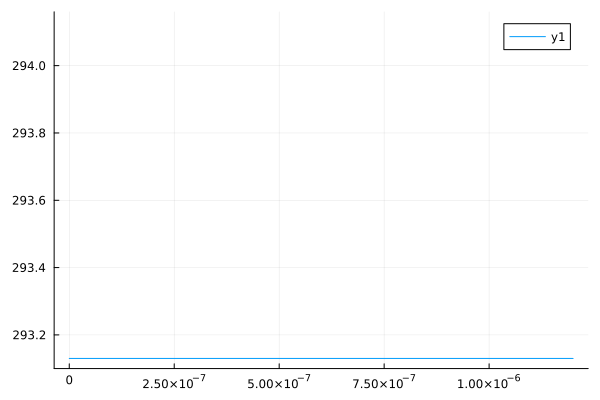

In [4]:
function Tfun(u)  
    if u <= uTran
      return ((TAppMax - TAppMin)/uTran)*u + TAppMin
    else
     return  TAppMax
    end
end 
plot(Tfun,0,uMax)

In [5]:
uAppVec = range(0,uMax,length = Int64(floor((tMax/delt)+1)));
TAppVec = Tfun.(uAppVec);

In [6]:
 L = 25e-3
 B = 5.0e-3
 lsp = L/200
 hf = lsp/4
 h = lsp/4

gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)
gmsh.model.geo.addPoint(0.0, B, 0.0, h, 1)  
gmsh.model.geo.addPoint(0.0, 0.0, 0.0, h, 2) 
gmsh.model.geo.addPoint(L, 0.0, 0.0,h, 3) 
gmsh.model.geo.addPoint(L, 0.3*B, 0.0, h, 4)
gmsh.model.geo.addPoint(L, B, 0.0, h, 5)
gmsh.model.geo.addPoint(0.3*L, B, 0.0, h, 6)
gmsh.model.geo.addPoint(0.3*L, 0.3*B, 0.0, h, 7)

gmsh.model.geo.addLine(1, 2, 1)
gmsh.model.geo.addLine(2, 3, 2)
gmsh.model.geo.addLine(3, 4, 3)
gmsh.model.geo.addLine(4, 5, 4)
gmsh.model.geo.addLine(5, 6, 5)
gmsh.model.geo.addLine(6, 1, 6)
gmsh.model.geo.addLine(6, 7, 7)
gmsh.model.geo.addLine(7, 4, 8)

gmsh.model.geo.addCurveLoop([1,2,3,4,5,6],1)


gmsh.model.geo.addCurveLoop([7,8,4,5],11)
gmsh.model.geo.addPlaneSurface([11], 11)
gmsh.model.geo.addPlaneSurface([1,-11], 1)

gmsh.model.addPhysicalGroup(2, [1,11],1)
gmsh.model.addPhysicalGroup(1, [3,4],1)
gmsh.model.addPhysicalGroup(1, [6,5],2)
gmsh.model.addPhysicalGroup(1, [1,2],3)
gmsh.model.setPhysicalName(2, 1, "Domain")
gmsh.model.setPhysicalName(1, 1, "VerticalSupport")
gmsh.model.setPhysicalName(1, 2, "HorizontalSupport")
gmsh.model.setPhysicalName(1, 3, "TempBoundary")

gmsh.model.mesh.field.add("Distance", 1)
gmsh.model.mesh.field.setNumbers(1, "EdgesList", [6,1,2,3,8,7])

gmsh.model.mesh.field.add("Threshold", 2)
gmsh.model.mesh.field.setNumber(2, "IField", 1)
gmsh.model.mesh.field.setNumber(2, "LcMin", hf)
gmsh.model.mesh.field.setNumber(2, "LcMax", h)
gmsh.model.mesh.field.setNumber(2, "DistMin", 0.2*B)
gmsh.model.mesh.field.setNumber(2, "DistMax", 0.4*B)

gmsh.model.mesh.field.setAsBackgroundMesh(2)

gmsh.model.geo.synchronize()
gmsh.model.mesh.generate(2)
gmsh.write("Quenching.msh")
gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 70%] Meshing curve 6 (Line)
Info    : [ 80%] Meshing curve 7 (Line)
Info    : [ 90%] Meshing curve 8 (Line)
Info    : Done meshing 1D (Wall 0.00265121s, CPU 0s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 11 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 5.45441s, CPU 5.35938s)
Info    : 149413 nodes 299503 elements
Info    : Writing 'Quenching.msh'...
Info    : Done writing 'Quenching.msh'


In [7]:
model = GmshDiscreteModel("Quenching.msh")
writevtk(model,"Quenching")

Info    : Reading 'Quenching.msh'...
Info    : 17 entities
Info    : 149413 nodes
Info    : 298824 elements                                                                                     
Info    : Done reading 'Quenching.msh'                                                                           


3-element Vector{Vector{String}}:
 ["Quenching_0.vtu"]
 ["Quenching_1.vtu"]
 ["Quenching_2.vtu"]

In [8]:
const ψI_Crit = 0.5*σ1_crit^2/E
const ψII_Crit = β*ψI_Crit
m1(GcI) = (3 * GcI)  / (8*lsp*ψI_Crit)
m2(GcII) = (3 * GcII) / (8*lsp*ψII_Crit)
p = -0.5

-0.5

In [9]:
E_Matrx = TensorValue(0,1,-1,0)

TensorValue{2, 2, Int64, 4}(0, 1, -1, 0)

In [10]:
function degDer1(ϕ,Gc_eff)
    m = m1(Gc_eff)
    g1 = ((2*ϕ^3+(2*m*ϕ*(1-ϕ)*(1+(p*(1-ϕ))))) - (2*ϕ^3-(m*ϕ^2*(1+(p*(1-ϕ))))-(m*p*ϕ^2*(1-ϕ)))) / (ϕ^2+(m*(1-ϕ)*(1+(p*(1-ϕ)))))^2
    return g1
end

degDer1 (generic function with 1 method)

In [11]:
function degDer2(ϕ,Gc_eff)
    m = m2(Gc_eff)
    g2 = ((2*ϕ^3+(2*m*ϕ*(1-ϕ)*(1+(p*(1-ϕ))))) - (2*ϕ^3-(m*ϕ^2*(1+(p*(1-ϕ))))-(m*p*ϕ^2*(1-ϕ)))) / (ϕ^2+(m*(1-ϕ)*(1+(p*(1-ϕ)))))^2
    return g2
end

degDer2 (generic function with 1 method)

In [12]:
I2 = SymTensorValue{2,Float64}(1.0 ,0.0 ,1.0)
I4 = I2 ⊗ I2
I4_sym = one(SymFourthOrderTensorValue{dimension,Float64})
I4_vol = (1.0/dimension)*I4
I4_dev = I4_sym  - I4_vol

SymFourthOrderTensorValue{2, Float64, 9}(0.5, 0.0, -0.5, 0.0, 0.5, 0.0, -0.5, 0.0, 0.5)

In [13]:
function spectral(ε)
    εArray = get_array(ε)
    Λ, P = eigen(εArray)
    ε1 = Λ[1]
    ε2 = Λ[2]
    if ε1 >= 0 &&  ε2 >= 0
        Λpos = [ε1 0; 0 ε2]
        Λneg = [0 0; 0 0]
    elseif ε1 >= 0 &&  ε2 < 0
        Λpos = [ε1 0; 0 0]
        Λneg = [0 0; 0 ε2]
    elseif ε1 < 0 &&  ε2 >= 0
        Λpos = [0 0; 0 ε2]
        Λneg = [ε1 0; 0 0]
    elseif ε1 < 0 &&  ε2 < 0
        Λpos = [0 0; 0 0]
        Λneg = [ε1 0; 0 ε2]
    end 
    εPos = TensorValue(P*Λpos*P')
    εNeg = TensorValue(P*Λneg*P')
    return εPos, εNeg 
end

spectral (generic function with 1 method)

In [14]:
function σ_elasMod(ε,ε_in , s_in ,T,T_Prev,Gc_eff)
    εElas_in = ε_in - α*(T_Prev -T_ambient)*I2
    εElas = ε - α*(T-T_ambient)*I2
    mI = m1(Gc_eff)
    mII = m2(Gc_eff)
    gs1 = (s_in^2) / (s_in^2 + mI*(1-s_in)*(1+(p*(1-s_in))))
    gs2 = (s_in^2) / (s_in^2 + mII*(1-s_in)*(1+(p*(1-s_in))))
        σ = (gs1+η)*λ*tr(εElas)*one(εElas) + (gs2+η)*(2*μ + κ)*εElas
    return σ
end

σ_elasMod (generic function with 1 method)

In [15]:
function σ_totMod(ε,ε_in ,s_in, T_Prev,Gc_eff)
    εElas_in = ε_in - α*(T_Prev -T_ambient)*I2
    εElasTot = ε
    mI = m1(Gc_eff)
    mII = m2(Gc_eff)
    gs1 = (s_in^2) / (s_in^2 + mI*(1-s_in)*(1+(p*(1-s_in))))
    gs2 = (s_in^2) / (s_in^2 + mII*(1-s_in)*(1+(p*(1-s_in))))
        σU = (gs1+η)*λ*tr(εElasTot)*one(εElasTot) + (gs2+η)*(2*μ + κ)*εElasTot
    return σU
end

σ_totMod (generic function with 1 method)

In [16]:
function σ_totthMod(ε_in ,s_in, T, T_Prev,Gc_eff)
    εElas_in = ε_in - α*(T_Prev -T_ambient)*I2
    εElasTotth = -α*T*I2
    mI = m1(Gc_eff)
    mII = m2(Gc_eff)
    gs1 = (s_in^2) / (s_in^2 + mI*(1-s_in)*(1+(p*(1-s_in))))
    gs2 = (s_in^2) / (s_in^2 + mII*(1-s_in)*(1+(p*(1-s_in))))
    σT = (gs1+η)*λ*tr(εElasTotth)*one(εElasTotth) + (gs2+η)*(2*μ + κ)*εElasTotth
    return σT
end

σ_totthMod (generic function with 1 method)

In [17]:
function σ_thermMod(ε_in ,s_in ,T_Prev,Gc_eff)
    εElas_in = ε_in - α*(T_Prev -T_ambient)*I2
    εElasTher = α*(T_ambient)*I2
    mI = m1(Gc_eff)
    mII = m2(Gc_eff)
    gs1 = (s_in^2) / (s_in^2 + mI*(1-s_in)*(1+(p*(1-s_in))))
    gs2 = (s_in^2) / (s_in^2 + mII*(1-s_in)*(1+(p*(1-s_in))))
    σF = (gs1+η)*λ*tr(εElasTher)*one(εElasTher) + (gs2+η)*(2*μ + κ)*εElasTher
    return σF
end

σ_thermMod (generic function with 1 method)

In [18]:
function Skw(u,θ)
    ∇ᵀ = transpose(∇(u))
    w = (0.5*(∇ᵀ) - (E_Matrx*θ))
    return w
end
    
function ε_Skw(∇,θ)
    ∇ᵀ = transpose(∇)
    w = (0.5*(∇ᵀ - ∇)) - (E_Matrx*θ)
    return w
end

function σ_Cmod(ϵ_skew, s_in,Gc_eff)
    mII = m2(Gc_eff)
    gs2 = (s_in^2) / (s_in^2 + mII*(1-s_in)*(1+(p*(1-s_in))))
    σM = (gs2)*(κ*ϵ_skew)
    return σM
end

function M_mod(∇, s_in,Gc_eff)
    mII = m2(Gc_eff)
    gs2 = (s_in^2) / (s_in^2 + mII*(1-s_in)*(1+(p*(1-s_in))))
    M = (gs2)*(γ*∇)
    return M
end

M_mod (generic function with 1 method)

In [19]:
function ΨPosI(ε_in ,T_Prev,∇_uh,θ, ∇_th)
    ∇_uhᵀ = transpose(∇_uh)
    εElas_in = ε_in - α*(T_Prev -T_ambient)*I2
    ϵ_skew = 0.5*(∇_uhᵀ - ∇_uh) - E_Matrx*θ
    εPos, εNeg = spectral(εElas_in)

    if tr(εElas_in)  >= 0
        ΨPlus = 0.5*(λ*(tr(εElas_in))^2)
    else
        ΨPlus = 0.0
    end
    return ΨPlus
end

ΨPosI (generic function with 1 method)

In [20]:
function ΨPosII(ε_in ,T_Prev,∇_uh,θ, ∇_th)
    ∇_uhᵀ = transpose(∇_uh)
    εElas_in = ε_in - α*(T_Prev -T_ambient)*I2
    ϵ_skew = 0.5*(∇_uhᵀ - ∇_uh) - E_Matrx*θ
    εPos, εNeg = spectral(εElas_in)
    if tr(εElas_in)  >= 0
        ΨPlus = (0.5*(2*μ+κ)*((εPos ⊙ εPos))) + (0.5*(κ*(ϵ_skew ⊙ ϵ_skew))) + (0.5*γ*(∇_th ⋅ ∇_th))
    else
        ΨPlus = (0.5*(2*μ+κ)*((εPos ⊙ εPos))) + (0.5*(κ*(ϵ_skew ⊙ ϵ_skew))) + (0.5*γ*(∇_th ⋅ ∇_th))
    end
    return ΨPlus
end


ΨPosII (generic function with 1 method)

In [21]:
function ΨCoupling(∇_uh,θ)

    ∇_uhᵀ = transpose(∇_uh)

    ϵ_skew = 0.5*(∇_uhᵀ - ∇_uh) - E_Matrx*θ

    return 0.5*(κ*(ϵ_skew ⊙ ϵ_skew))

end

ΨCoupling (generic function with 1 method)

In [22]:
function ΨRot(∇_th)

    return 0.5*γ*(∇_th ⋅ ∇_th)

end

ΨRot (generic function with 1 method)

In [23]:
order = 1
reffe_PF = ReferenceFE(lagrangian ,Float64 ,order)
V0_PF = TestFESpace(model ,reffe_PF;conformity =:H1)

UnconstrainedFESpace()

In [24]:
reffe_Disp = ReferenceFE(lagrangian,VectorValue{2,Float64},order)
        V0_Disp = TestFESpace(model,reffe_Disp;
          conformity=:H1,
          dirichlet_tags=["VerticalSupport","HorizontalSupport"],
          dirichlet_masks=[(true,false),(false,true)])
uh = zero(V0_Disp)

SingleFieldFEFunction():
 num_cells: 296904
 DomainStyle: ReferenceDomain()
 Triangulation: BodyFittedTriangulation()
 Triangulation id: 2846462320076052141

In [25]:
reffe_theta = ReferenceFE(lagrangian,Float64,order)
V0_theta  = TestFESpace(model,reffe_theta;conformity=:H1)
θh = zero(V0_theta)

SingleFieldFEFunction():
 num_cells: 296904
 DomainStyle: ReferenceDomain()
 Triangulation: BodyFittedTriangulation()
 Triangulation id: 2846462320076052141

In [26]:
reffe_Temp = ReferenceFE(lagrangian ,Float64 ,order)
V0_Temp = TestFESpace(model ,reffe_Temp;
    conformity =:H1 ,dirichlet_tags =["TempBoundary"])

UnconstrainedFESpace()

In [27]:
V0 = MultiFieldFESpace([V0_Disp,V0_theta,V0_Temp])

MultiFieldFESpace()

In [28]:
degree = 2* order
Ω= Triangulation(model)
dΩ= Measure(Ω,degree)

GenericMeasure()

In [29]:
function  project(q,model ,dΩ,order)
    reffe = ReferenceFE(lagrangian ,Float64 ,order)
    V = FESpace(model ,reffe ,conformity =:L2)
    a(u,v) =∫(u*v)*dΩ
    b(v) =∫(v*q)*dΩ
    op = AffineFEOperator(a,b,V,V)
    qh = Gridap.solve(op)
    return  qh
end

project (generic function with 1 method)

In [30]:
nls = NLSolver(
  show_trace=true,
  method=:newton,
  linesearch=BackTracking(), iterations = 10)
solver = FESolver(nls)

NonlinearFESolver()

In [31]:
function stepPhaseField(x0,cache,Y1,Y2,Gc_eff)
     U_PF = TrialFESpace(V0_PF)
     res(s,ϕ) = ∫( (3/4)*Gc_eff*lsp*(∇(ϕ)⋅ ∇(s)) + (((degDer1∘(s,Gc_eff))*(Y1)))*ϕ + ((degDer2∘(s,Gc_eff))*(Y2))*ϕ - (Gc_eff*(3/(8*lsp))*ϕ))*dΩ
     op = FEOperator(res,U_PF,V0_PF)
     sh_out = FEFunction(U_PF,x0)
     sh_out, cache = solve!(sh_out,solver,op,cache)
  return sh_out, get_free_dof_values(sh_out), cache
end

stepPhaseField (generic function with 1 method)

In [32]:
function κGradTemp(∇,s_in)
    kGr = κ_mat*∇ 
    return kGr
end

κGradTemp (generic function with 1 method)

In [33]:
function    stepDispTemp(uh_in ,sh_in ,T_Prev ,θ_in,vApp,TApp ,delt,Gc_eff)
    uApp1(x) = VectorValue(0.0,0.0)
    uApp2(x) = VectorValue(0.0,0.0)
    U_Disp = TrialFESpace(V0_Disp,[uApp1,uApp2])
    U_theta = TrialFESpace(V0_theta)
    Tapp1(x) = TApp
    Tg = TrialFESpace(V0_Temp,[Tapp1])
    U = MultiFieldFESpace([U_Disp ,U_theta, Tg])

    a((u,θ,T) ,(v,w,z)) =∫( (ε(v) ⊙ (σ_totMod∘(ε(u),ε(uh_in),sh_in,T_Prev,Gc_eff) + σ_totthMod∘(ε(uh_in),sh_in,T,T_Prev,Gc_eff))) + 
                        ((Skw(v,w)) ⊙ (σ_Cmod∘(ε_Skw∘(∇(u),θ), sh_in,Gc_eff)) ) + ((∇(w))⋅ (M_mod∘(∇(θ),sh_in,Gc_eff))) - 
                        (w*((E_Matrx) ⊙ (σ_Cmod∘(ε_Skw∘(∇(u),θ),sh_in,Gc_eff)))) + (∇(z)⋅(κGradTemp∘(∇(T),sh_in))) + (((ρ*c*T*z)/delt)))*dΩ

    b((v,w,z)) =∫(((ρ*c*T_Prev*z)/delt) - (ε(v)⊙(σ_thermMod∘(ε(uh_in),sh_in ,T_Prev,Gc_eff))))*dΩ


    op = AffineFEOperator(a,b,U,V0)
    uhTh = Gridap.solve(op)
    uh_out ,θh_out,Th_out =   uhTh
    return  uh_out ,θh_out, Th_out
end

stepDispTemp (generic function with 1 method)

In [34]:
function Gvalue(k)
    Gv = (GcI*(1-k)+GcII*k)
    return Gv
end

Gvalue (generic function with 1 method)

In [35]:
function new_EnergyState(ψPlusPrev_in,ψhPos_in)
    ψPlus_in = ψhPos_in
    if ψPlus_in >= ψPlusPrev_in
        ψPlus_out = ψPlus_in
    else
        ψPlus_out = ψPlusPrev_in
    end
    true,ψPlus_out
end

new_EnergyState (generic function with 1 method)

In [36]:
output_dir = "Quench_T$(T_ambient)_N$(N)_lb$(l)_betag$(βg)_betas$(β)"
if !isdir(output_dir)
    mkdir(output_dir) 
    end

"Quench_T573.15_N0.5_lb0.0003_betag2.0_betas1.25"

In [ ]:
tMin = 0
vApp = 0
innerMax = 10
stepcount = 0
tol = 1e-5

sPrev = CellState(1.0,dΩ)
sh = project(sPrev ,model ,dΩ,order)
ThPrev = CellState(T_ambient,dΩ)
Th = project(ThPrev ,model ,dΩ,order)
x0_PF = ones(Float64,num_free_dofs(V0_PF))
cache_1 = nothing
ψhPos = CellState(0.0,dΩ)
ψhPos_in = project(ψhPos,model,dΩ,order)
H_I_prev  = CellState(0.0, dΩ)
H_II_prev = CellState(0.0, dΩ)
k = project(0.0, model, dΩ, order)

H_I_n = project(H_I_prev,  model, dΩ, order)
H_II_n = project(H_II_prev,  model, dΩ, order)

k = (((H_II_n/ψII_Crit)+η) / ((((H_I_n/ψI_Crit)+η) + ((H_II_n/ψII_Crit)+η))))

Gc_eff = Gvalue(k)

while tMin .< tMax
    stepcount = stepcount  .+ 1
    tMin = tMin + delt
    vApp = AppVel*tMin  
    TApp = TAppVec[stepcount] 

    Iter_used = 0
    print("\n Entering  time  step $stepcount :", float(tMin))
   
    for  inner = 1:innerMax
        Iter_used = inner
        
        uh, θh, Th = stepDispTemp(uh,sh ,Th,θh,vApp,TApp ,delt,Gc_eff)  
        
        H_I = ΨPosI ∘ (ε(uh), Th, ∇(uh), θh, ∇(θh))
        H_II = ΨPosII ∘ (ε(uh), Th, ∇(uh), θh, ∇(θh))
        update_state!(new_EnergyState, H_I_prev,  H_I)
        update_state!(new_EnergyState, H_II_prev, H_II)
        H_I_n = project(H_I_prev,  model, dΩ, order)
        H_II_n = project(H_II_prev,  model, dΩ, order)

        kp = (((H_II_n/ψII_Crit)) / (((H_I_n/ψI_Crit)) + ((H_II_n/ψII_Crit))))
        k = project(kp,model,dΩ,order)

        Gc_eff = Gvalue(k)

        modeIth = (1-k) * ψI_Crit
        modeIIth = k * ψII_Crit
        update_state!(new_EnergyState, H_I_prev, modeIth)
        update_state!(new_EnergyState, H_II_prev, modeIIth)
         
        Y1 = project(H_I_prev, model, dΩ, order)
        Y2 = project(H_II_prev, model, dΩ, order)

        
        
        RelErr = abs(sum(∫( ((3/4)*Gc_eff*lsp*∇(sh)⋅ ∇(sh)) + ((degDer1∘(sh,Gc_eff))*(Y1)*sh) + ((degDer2∘(sh,Gc_eff))*Y2*sh))*dΩ 
                        - ∫( ((3/8)/lsp)*Gc_eff*sh)*dΩ))/abs(sum(∫( ((3/8)/lsp)*Gc_eff*sh)*dΩ))
          print("\n Relative error = ",float(RelErr))  
          
          sh, x0_PF, cache_1 = stepPhaseField(x0_PF, cache_1, Y1, Y2, Gc_eff)
        
        if  (RelErr  < tol)
            break            
        end
        
    end

    if mod(stepcount,10) == 0
    writevtk(Ω,"Quench_T$(T_ambient)_N$(N)_lb$(l)_betag$(βg)_betas$(β)/Check_$T_ambient$stepcount",cellfields=["uh"=>uh,"s"=>sh ,"epsi"=>ε(uh),"T"=>Th, "θ"=>θh, "k"=>k])
    end
end